# TCAV — Testing with Concept Activation Vectors

**Companion to** [research/03-tcav.md](../research/03-tcav.md)

TCAV (Kim et al., 2018) asks: *does the model **use** a human-defined concept when it predicts a
class?* It first learns a **Concept Activation Vector** $v_C^\ell$ — the normal of a linear
classifier separating "concept" activations from random ones — then measures the **directional
derivative** $S_{C,k,\ell}(x)=\nabla h_{\ell,k}\cdot v_C^\ell$ of the class-$k$ logit along that
direction. The **TCAV score** is the fraction of class-$k$ inputs with positive sensitivity.

**What we will see:**
1. A CAV is literally the normal vector of a concept-vs-random hyperplane.
2. The directional derivative turns that vector into a per-input sensitivity; its sign tally is the TCAV score.
3. A single score is meaningless — only a **significance test** against random concepts validates it.
4. CAVs are **unstable**: degrade the concept set and the score drifts (Ramaswamy et al., 2023).
5. TCAV rests on a **linear-separability assumption** — check CAV accuracy or the score is noise.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from scipy import stats
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## A controllable model with known concepts

We need a **differentiable** model so we can take gradients of a logit w.r.t. activations. We build a
synthetic dataset with interpretable factors: a **stripe** factor that drives the target class
(its effect *gated by a context factor*, so the model's sensitivity varies input-to-input — exactly
what makes TCAV scores graded rather than all-or-nothing), an independent **dots** factor, plus
other/noise dimensions. A 3-hidden-layer MLP `encode → rest` is trained; the first hidden layer is
the activation space where CAVs live, and the nonlinear layers after it make the logit's gradient
genuinely input-dependent.

In [2]:
def make_data(n, seed):
    rng = np.random.RandomState(seed)
    stripe = (rng.random(n) < 0.3).astype(int)    # concept that drives the class (~30% prevalent)
    dots = (rng.random(n) < 0.3).astype(int)       # an independent concept
    size = rng.randn(n)                            # context factor that gates stripe's effect
    other = rng.randn(n, 3)
    noise = rng.randn(n, 2) * 0.5
    x = np.column_stack([
        stripe * 2.0 + 0.3 * rng.randn(n),  # col 0: stripe signal
        dots * 2.0 + 0.3 * rng.randn(n),    # col 1: dots signal
        size,                               # col 2: context
        other,                              # cols 3-5
        noise,                              # cols 6-7
    ]).astype(np.float32)
    # stripe pushes toward class 1, but the push is gated by context -> per-input sensitivity varies
    logit = (2 * stripe - 1) * (0.7 + 0.8 * size)
    y = (logit > 0).astype(np.int64)
    return x, y, stripe, dots

X, y, stripe, dots = make_data(4000, 0)

class Net(nn.Module):
    def __init__(self, d=8, h=64):
        super().__init__()
        self.enc1 = nn.Linear(d, h)      # CAV lives at this layer's output
        self.enc2 = nn.Linear(h, h)
        self.enc3 = nn.Linear(h, h)
        self.head = nn.Linear(h, 2)
    def encode(self, x):                  # activation layer used by the CAV
        return torch.relu(self.enc1(x))
    def head_from_activation(self, a):    # rest of the net: a -> logits (nonlinear)
        return self.head(torch.relu(self.enc3(torch.relu(self.enc2(a)))))
    def forward(self, x):
        return self.head_from_activation(self.encode(x))

net = Net()
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
lossf = nn.CrossEntropyLoss()
Xt, yt = torch.tensor(X), torch.tensor(y)
for _ in range(800):
    opt.zero_grad(); loss = lossf(net(Xt), yt); loss.backward(); opt.step()
acc = (net(Xt).argmax(1).numpy() == y).mean()
print(f'Classifier accuracy: {acc:.3f}')

# helpers ----------------------------------------------------------
def activations(x_np):
    with torch.no_grad():
        return net.encode(torch.tensor(x_np)).numpy()

def learn_cav(pos_idx, neg_idx):
    A = np.vstack([activations(X[pos_idx]), activations(X[neg_idx])])
    lbl = np.r_[np.ones(len(pos_idx)), np.zeros(len(neg_idx))]
    clf = LogisticRegression(max_iter=1000).fit(A, lbl)
    w = clf.coef_[0]
    return w / np.linalg.norm(w), clf.score(A, lbl)

def directional_deriv(x_np, cav, k):
    # gradient of the class-k logit w.r.t. the CAV-layer activation (input-dependent because the
    # enc2/enc3 ReLUs sit between the activation and the logit)
    a = net.encode(torch.tensor(x_np)).detach().requires_grad_(True)
    logit_k = net.head_from_activation(a)[:, k]
    g, = torch.autograd.grad(logit_k.sum(), a)
    return g.numpy() @ cav            # S_{C,k}(x) for each input

def tcav_score(class_inputs, cav, k):
    return float((directional_deriv(class_inputs, cav, k) > 0).mean())

# concept-absent pool: TCAV negatives should NOT contain the concept
absent_stripe = np.where(stripe == 0)[0]
class_inputs = X[y == 1]              # X_k: inputs of the target class
print(f'class-1 inputs: {len(class_inputs)},  stripe-positive: {stripe.sum()}')
print('Helpers ready.')

Classifier accuracy: 1.000
class-1 inputs: 1555,  stripe-positive: 1208
Helpers ready.


### What you see

The classifier fits the gated rule well. Two design choices matter for the rest of the notebook:
**(1)** the model is differentiable — `encode` maps an input to a 64-D hidden activation, and
`head_from_activation` carries that through two more nonlinear layers to the logits, so the gradient
$\nabla h_k$ genuinely varies across inputs; **(2)** TCAV negatives are drawn from the
**concept-absent pool** (`absent_stripe`), matching the method's "random images that lack the
concept". The three helpers implement `learn_cav`, the directional derivative, and the score.

## Experiment 1: A CAV is the normal of a concept-vs-random hyperplane

**Question:** Geometrically, what *is* a CAV?

We collect activations for **stripe-positive** inputs and **concept-absent** counterexamples, fit a
linear classifier, and draw its normal. To see it in 2D we project the 64-D activations onto the
plane spanned by the CAV and the top orthogonal variance direction.

In [3]:
np.random.seed(11)
pos = np.where(stripe == 1)[0]
rand_neg = np.random.choice(absent_stripe, size=len(pos), replace=False)
cav, cav_acc = learn_cav(pos, rand_neg)
print(f'CAV separability accuracy: {cav_acc:.3f}')

A_all = activations(X)
A_c = A_all - A_all.mean(0)
proj_on_cav = np.outer(A_c @ cav, cav)
resid = A_c - proj_on_cav
u, s, vt = np.linalg.svd(resid, full_matrices=False)
ortho = vt[0]
coord_x = A_c @ cav
coord_y = A_c @ ortho

CAV separability accuracy: 1.000


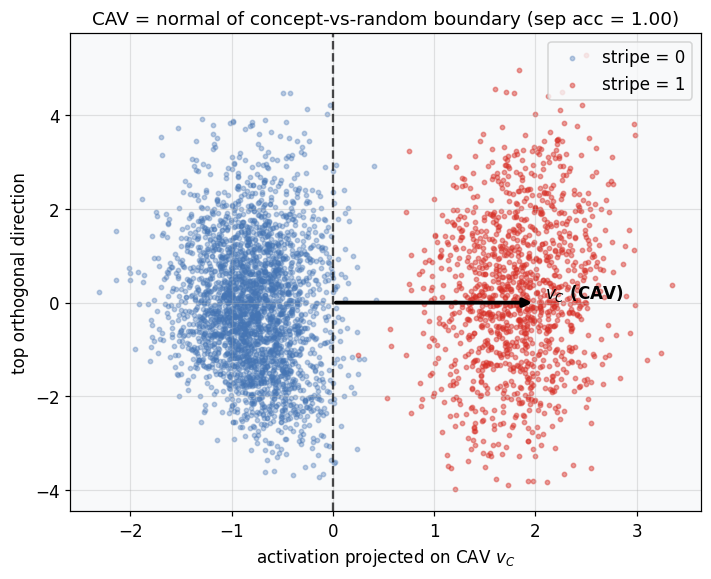

In [4]:
fig, ax = plt.subplots(figsize=(6.6, 5.4))
ax.scatter(coord_x[stripe == 0], coord_y[stripe == 0], s=8, c='#4575b4', alpha=0.35, label='stripe = 0')
ax.scatter(coord_x[stripe == 1], coord_y[stripe == 1], s=8, c='#d73027', alpha=0.45, label='stripe = 1')
ax.axvline(0, color='k', ls='--', lw=1.5, alpha=0.7)
ax.annotate('', xy=(2.0, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=2.5))
ax.text(2.1, 0.1, '$v_C$ (CAV)', fontsize=11, fontweight='bold')
ax.set_title(f'CAV = normal of concept-vs-random boundary (sep acc = {cav_acc:.2f})')
ax.set_xlabel('activation projected on CAV $v_C$')
ax.set_ylabel('top orthogonal direction')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

### What you see

Projected onto the CAV axis (horizontal), the stripe-positive activations (red) sit cleanly to one
side and the stripe-negative ones (blue) to the other — the dashed line is the learned boundary, and
the black arrow $v_C$ is its normal. The high separability accuracy means the concept lives along a
**single linear direction** in this activation space.

This is the exact same object a [linear probe](../research/01-linear-probing.md) returns; TCAV's only
structural difference here is that the negatives are *concept-absent images* rather than an opposing
labelled class. Everything that follows builds on top of this one vector.

## Experiment 2: Directional derivative → TCAV score

**Question:** How does a direction become a number that says "the model uses this concept"?

For every class-1 input we compute $S_{C,k}(x)=\nabla h_{k}\cdot v_C$ — the change in the class-1
logit when we nudge the activation toward "more stripe". The TCAV score is the fraction with $S>0$.
We contrast the **stripe** concept against a pool of **random directions** (the null): a meaningful
concept pushes the logit consistently one way, a random direction does not.

In [5]:
np.random.seed(12)
S_stripe = directional_deriv(class_inputs, cav, k=1)
tcav_stripe = float((S_stripe > 0).mean())

# null: pool directional derivatives over many random unit directions
m = activations(class_inputs[:1]).shape[1]
rng = np.random.RandomState(7)
S_random_pool, random_scores = [], []
for _ in range(40):
    v = rng.randn(m); v /= np.linalg.norm(v)
    S = directional_deriv(class_inputs, v, k=1)
    S_random_pool.append(S); random_scores.append((S > 0).mean())
S_random_pool = np.concatenate(S_random_pool)
mean_random_score = float(np.mean(random_scores))
print(f'TCAV score  stripe          = {tcav_stripe:.3f}')
print(f'mean score  random concepts = {mean_random_score:.3f}')

TCAV score  stripe          = 0.810
mean score  random concepts = 0.463


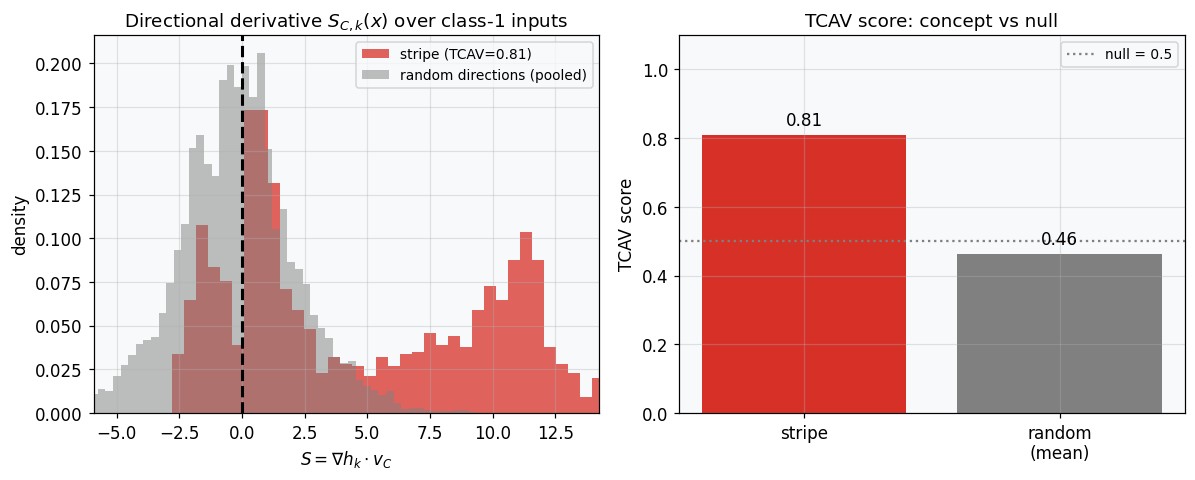

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
# normalise both for shape comparison
ax.hist(S_stripe, bins=40, density=True, color='#d73027', alpha=0.75, label=f'stripe (TCAV={tcav_stripe:.2f})')
ax.hist(S_random_pool, bins=60, density=True, color='gray', alpha=0.5, label='random directions (pooled)')
ax.axvline(0, color='k', ls='--', lw=2)
ax.set_xlim(np.percentile(S_random_pool, 1), np.percentile(S_stripe, 99))
ax.set_title('Directional derivative $S_{C,k}(x)$ over class-1 inputs')
ax.set_xlabel('$S = \\nabla h_k \\cdot v_C$'); ax.set_ylabel('density'); ax.legend(fontsize=9)
ax = axes[1]
ax.bar(['stripe', 'random\n(mean)'], [tcav_stripe, mean_random_score], color=['#d73027', 'gray'])
ax.axhline(0.5, color='gray', ls=':', label='null = 0.5')
for i, v in enumerate([tcav_stripe, mean_random_score]):
    ax.annotate(f'{v:.2f}', (i, v), textcoords='offset points', xytext=(0, 6), ha='center')
ax.set_ylim(0, 1.1); ax.set_ylabel('TCAV score'); ax.set_title('TCAV score: concept vs null'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

The stripe sensitivity distribution (red) is shifted firmly to the right of zero: for the large
majority of class-1 inputs, pushing toward "more stripe" *raises* the class logit, giving a high TCAV
score. The pooled random-direction sensitivities (gray) sit symmetrically around zero — a random
direction is just as likely to raise as to lower the logit, so its expected score is 0.5.

The score collapses a class's worth of gradients into one interpretable number: *how consistently
does this concept drive this class?* Note the gating makes stripe's score **graded** (not a flat 1.0)
— some contexts mute the effect — which is exactly how real TCAV scores behave. The contrast that
matters is concept-vs-null, and the next experiment makes that comparison rigorous.

## Experiment 3: A single score is meaningless — test for significance

**Question:** A random concept also produces *some* TCAV score. How do we know stripe's score is real?

The original method trains **many** CAVs (here, different concept-absent negative sets) to get a
*distribution* of scores for the true concept, and compares it against scores from **random
concepts** (random positive sets) with a two-sided t-test. Only a statistically separated score
counts.

In [7]:
np.random.seed(13)
K = 80
# distribution for the TRUE concept: re-draw concept-absent negatives each run
true_scores = []
for _ in range(K):
    neg = np.random.choice(absent_stripe, size=len(pos), replace=False)
    v, _ = learn_cav(pos, neg)
    true_scores.append(tcav_score(class_inputs, v, 1))

# distribution for RANDOM concepts: random positive sets vs random negatives
random_scores = []
for _ in range(K):
    rp = np.random.choice(len(X), size=len(pos), replace=False)
    rn = np.random.choice(len(X), size=len(pos), replace=False)
    v, _ = learn_cav(rp, rn)
    random_scores.append(tcav_score(class_inputs, v, 1))

true_scores = np.array(true_scores); random_scores = np.array(random_scores)
t, p = stats.ttest_ind(true_scores, random_scores)
print(f'true concept   : mean={true_scores.mean():.3f}  std={true_scores.std():.3f}')
print(f'random concept : mean={random_scores.mean():.3f}  std={random_scores.std():.3f}')
print(f'two-sided t-test: t={t:.2f}, p={p:.2e}')

true concept   : mean=0.793  std=0.024
random concept : mean=0.575  std=0.376
two-sided t-test: t=5.14, p=8.03e-07


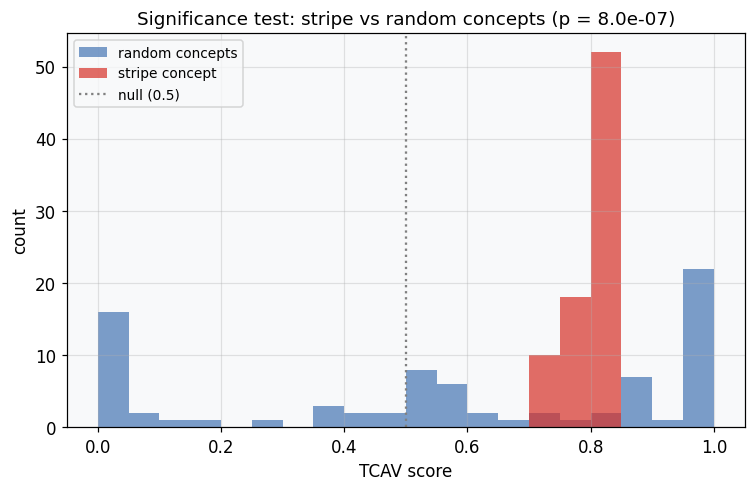

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.6))
bins = np.linspace(0, 1, 21)
ax.hist(random_scores, bins=bins, color='#4575b4', alpha=0.7, label='random concepts')
ax.hist(true_scores, bins=bins, color='#d73027', alpha=0.7, label='stripe concept')
ax.axvline(0.5, color='gray', ls=':', label='null (0.5)')
ax.set_title(f'Significance test: stripe vs random concepts (p = {p:.1e})')
ax.set_xlabel('TCAV score'); ax.set_ylabel('count'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

The random-concept scores (blue) scatter widely across $[0,1]$ — individually a random direction can
land anywhere, and only their *average* sits near 0.5. That spread is precisely why a single score is
untrustworthy. The stripe-concept scores (red) form a tight cluster well above the random mass, and
the t-test returns a vanishingly small p-value: stripe's effect is **statistically separable** from
the null.

This is why the note insists the significance test is *mandatory*. A lone TCAV score — even a
confident-looking one — could have come from a random direction. Latent-Anything therefore returns a
`p_value` alongside every score.

## Experiment 4: CAVs are unstable — the concept set matters

**Question:** How sensitive is the result to the quality of the concept examples?

Ramaswamy et al. (2023) show concept-based explanations depend heavily on the probe dataset. We
simulate a degrading concept set by mislabelling a growing fraction of the stripe-positive examples,
and watch the CAV's separability accuracy and the TCAV score both erode toward chance.

In [9]:
np.random.seed(14)
fracs = [0.0, 0.15, 0.3, 0.45, 0.6, 0.75]
cav_accs, scores = [], []
pos_all = np.where(stripe == 1)[0]
for fr in fracs:
    n_bad = int(fr * len(pos_all))
    bad = np.random.choice(absent_stripe, size=n_bad, replace=False)      # mislabelled (non-concept) examples
    keep = np.random.choice(pos_all, size=len(pos_all) - n_bad, replace=False)
    noisy_pos = np.r_[keep, bad]
    neg = np.random.choice(absent_stripe, size=len(noisy_pos), replace=False)
    v, a = learn_cav(noisy_pos, neg)
    cav_accs.append(a); scores.append(tcav_score(class_inputs, v, 1))
for fr, a, sc in zip(fracs, cav_accs, scores):
    print(f'mislabel {int(fr*100):2d}%  ->  CAV acc={a:.3f}  TCAV={sc:.3f}')

mislabel  0%  ->  CAV acc=1.000  TCAV=0.814
mislabel 15%  ->  CAV acc=0.922  TCAV=0.505
mislabel 30%  ->  CAV acc=0.842  TCAV=0.641
mislabel 45%  ->  CAV acc=0.762  TCAV=0.551
mislabel 60%  ->  CAV acc=0.694  TCAV=0.504
mislabel 75%  ->  CAV acc=0.623  TCAV=0.576


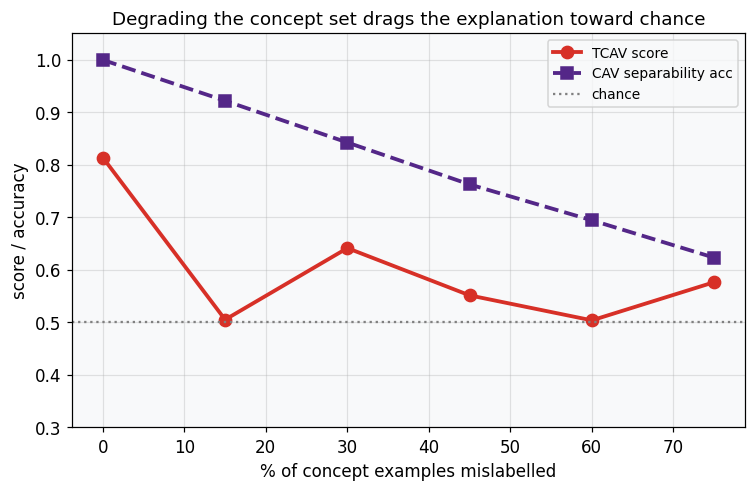

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.6))
xs = [int(f * 100) for f in fracs]
ax.plot(xs, scores, 'o-', lw=2.5, ms=8, color='#d73027', label='TCAV score')
ax.plot(xs, cav_accs, 's--', lw=2.5, ms=8, color='#542788', label='CAV separability acc')
ax.axhline(0.5, color='gray', ls=':', label='chance')
ax.set_title('Degrading the concept set drags the explanation toward chance')
ax.set_xlabel('% of concept examples mislabelled')
ax.set_ylabel('score / accuracy'); ax.set_ylim(0.3, 1.05); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

As more of the "stripe" set is polluted with concept-absent images, the CAV can no longer cleanly
separate concept from random (purple drops toward 0.5), and its direction loses alignment with the
true stripe axis, so the TCAV score drifts down with it. The *same model and class* yield a weaker,
less trustworthy explanation purely because the concept dataset changed.

This is the instability Ramaswamy et al. warn about: a TCAV result is only as good as the curated
examples behind it. In practice, **report the CAV's separability accuracy as a health check** — it is
the earliest warning that a score should not be trusted.

## Experiment 5 (limitation): the linear-separability assumption

**Question:** What if the concept is *not* a single linear direction in activation space?

A CAV is a **linear** classifier — it can only capture a concept that is linearly separable in the
chosen layer. We define an **XOR concept** (present iff two underlying factors disagree) and compare,
in the same activation space, how well a **linear** probe (the CAV) separates it versus a **nonlinear
(MLP)** probe. A large gap means the concept exists but is *not* a linear direction — so the CAV, and
any TCAV score built on it, is invalid.

In [11]:
np.random.seed(15)
f_a = (X[:, 3] > 0).astype(int)
f_b = (X[:, 4] > 0).astype(int)
xor_concept = (f_a ^ f_b)

def mlp_separability(pos_idx, neg_idx):
    A = np.vstack([activations(X[pos_idx]), activations(X[neg_idx])])
    lbl = np.r_[np.ones(len(pos_idx)), np.zeros(len(neg_idx))]
    return MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=2000,
                         random_state=0).fit(A, lbl).score(A, lbl)

pos_lin = np.where(stripe == 1)[0]
xor_pos_all = np.where(xor_concept == 1)[0]
xor_neg_all = np.where(xor_concept == 0)[0]
m_xor = min(len(xor_pos_all), len(xor_neg_all))
pos_xor = np.random.choice(xor_pos_all, size=m_xor, replace=False)
neg_lin = np.random.choice(absent_stripe, size=len(pos_lin), replace=False)
neg_xor = np.random.choice(xor_neg_all, size=m_xor, replace=False)

cav_lin, lin_cavacc = learn_cav(pos_lin, neg_lin)     # CAV = linear separability
cav_xor, xor_cavacc = learn_cav(pos_xor, neg_xor)
lin_mlpacc = mlp_separability(pos_lin, neg_lin)        # nonlinear separability
xor_mlpacc = mlp_separability(pos_xor, neg_xor)
print(f'linear concept : CAV(linear) acc={lin_cavacc:.3f}   MLP acc={lin_mlpacc:.3f}')
print(f'XOR concept    : CAV(linear) acc={xor_cavacc:.3f}   MLP acc={xor_mlpacc:.3f}')
print(f'XOR linear-vs-nonlinear gap: {xor_mlpacc - xor_cavacc:.3f}')

linear concept : CAV(linear) acc=1.000   MLP acc=1.000
XOR concept    : CAV(linear) acc=0.781   MLP acc=1.000
XOR linear-vs-nonlinear gap: 0.219


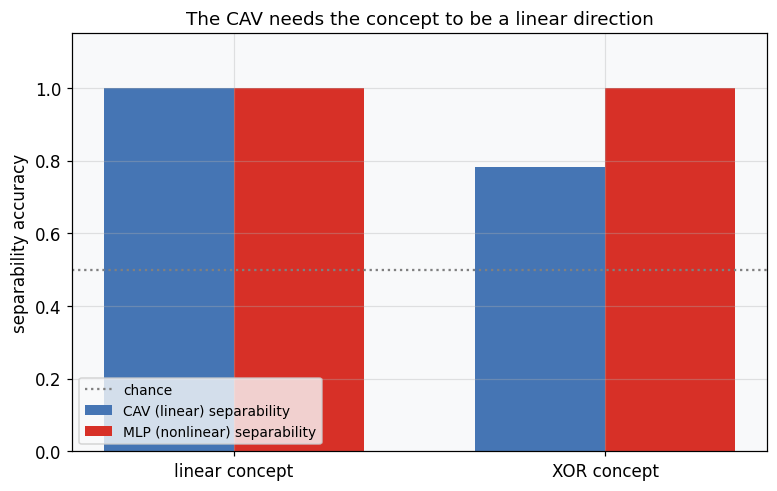

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
x = np.arange(2); width = 0.35
ax.bar(x - width / 2, [lin_cavacc, xor_cavacc], width, label='CAV (linear) separability', color='#4575b4')
ax.bar(x + width / 2, [lin_mlpacc, xor_mlpacc], width, label='MLP (nonlinear) separability', color='#d73027')
ax.axhline(0.5, color='gray', ls=':', label='chance')
ax.set_xticks(x); ax.set_xticklabels(['linear concept', 'XOR concept'])
ax.set_ylim(0, 1.15); ax.set_ylabel('separability accuracy')
ax.set_title('The CAV needs the concept to be a linear direction')
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout(); plt.show()

### What you see

For the linear concept, the linear CAV and the nonlinear MLP separate it equally well — the concept
*is* a single direction, so the CAV is valid. For the **XOR** concept a gap opens: the MLP separates
it markedly better than the linear CAV can. That gap is the diagnosis — the concept genuinely exists
in the activations (the MLP finds it) but it is **not a linear direction**, so the CAV is the wrong
tool and any TCAV score built on it is an artifact.

The lesson: **always read the CAV's separability accuracy first**, and be suspicious when a nonlinear
probe beats it. TCAV's whole edifice assumes the concept is a linear direction; when it isn't, you
need [nonlinear probing](../research/02-nonlinear-probing.md) to confirm the concept exists, and TCAV
simply does not apply. This is the boundary of the method.

## Summary / Key Takeaways

- **Exp 1** — A CAV is the **normal vector** of a concept-vs-random hyperplane in activation space —
  the same kind of direction a linear probe returns.
- **Exp 2** — The **directional derivative** $\nabla h_k\cdot v_C$ gives per-input sensitivity; the
  **TCAV score** is the fraction positive — high and consistent for a real concept, ~0.5 for the null.
- **Exp 3** — A lone score is meaningless; random concepts scatter across $[0,1]$, so only a **t-test
  against the random-concept distribution** (here p ≪ 0.001) certifies a result.
- **Exp 4** — CAVs are **unstable**: degrading the concept set drags both CAV accuracy and the score
  toward chance, so the explanation is only as good as the probe dataset (Ramaswamy et al.).
- **Exp 5** — TCAV assumes the concept is **linearly separable**; for an XOR concept a nonlinear probe
  beats the linear CAV (a clear gap), so the concept isn't a direction and the score is an artifact —
  always check CAV separability first.
